## Introducción

El objetivo de este análisis es evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas.
Para ello, se hizo uso de datos reales de TomTom Traffic Index y OECD Cities, con el fin de identificar en qué ciudades conviene invertir en infraestructura de transporte.

## 🧩 Paso 1: Cargar y explorar


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')

In [ ]:
traffic.head()

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [ ]:
eco.head()

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"



---

## 🧩Paso 2: Explorar, limpiar y preparar los datos



In [ ]:
traffic.head(3)

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232


In [ ]:
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

En la estructura del DF traffic, se observa que:
- Las columnas `UpdateTimeUTC` y `UpdateTimeUTC` son de tipo texto(object) deben de ser datetime


In [ ]:
# Examinar la estructura de eco
eco.head(3)

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"


In [ ]:
eco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


En la estructura del DF eco, se observa que:
- Las columnas `City GDP/capita`, `Unemployment %`, ...son texto en vez de int64
- ...

### 2.2 Renombrar columnas



In [ ]:
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

In [ ]:
traffic.columns=["country","city","update_time_utc","jams_delay","traffic_index_live","jams_lenght_in_km","jams_count","traffic_index_week_ago","update_time_utc_week_ago","travel_time_live_per_10kms_mins",\
                "travel_time_historic_per_10kms_mins","mins_delay"]

# verificar cambios
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_lenght_in_km', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins',
       'travel_time_historic_per_10kms_mins', 'mins_delay'],
      dtype='object')

In [ ]:
eco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


In [ ]:

eco.columns=["year","city","country","city_gdp_capita","unemployement_%","pm2.5_(μg/m³)","population_m"]
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployement_%',
       'pm2.5_(μg/m³)', 'population_m'],
      dtype='object')


### 2.3 Corregir formatos numéricos y de fecha




<details>
<summary>Haz clic para ver la pista</summary>
para eliminar símbolos, puedes reemplazarlos por un texto vacío.

In [ ]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic["update_time_utc"],errors="coerce", utc=True)
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic["update_time_utc_week_ago"],errors="coerce", utc=True)

# verificar el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                               Non-Null Count    Dtype              
---  ------                               --------------    -----              
 0   country                              1004464 non-null  object             
 1   city                                 1004464 non-null  object             
 2   update_time_utc                      1004464 non-null  datetime64[ns, UTC]
 3   jams_delay                           1004464 non-null  float64            
 4   traffic_index_live                   1004464 non-null  float64            
 5   jams_lenght_in_km                    1004464 non-null  float64            
 6   jams_count                           1004464 non-null  float64            
 7   traffic_index_week_ago               1004464 non-null  float64            
 8   update_time_utc_week_ago             1004464 non-null  datetime64[ns, UTC]
 9   tr

In [ ]:
# Limpia separadores y convierte columnas numéricas en eco
eco['city_gdp_capita'] = eco["city_gdp_capita"].astype(str).str.strip().str.replace(".","",regex=False).str.replace(",",".") .astype(float)
eco['unemployment_pct'] = eco["unemployement_%"].astype(str).str.strip().str.replace("%","").str.replace(",",".",regex=False).astype(float)
eco['population_m'] = eco["population_m"].astype(str).str.strip().str.replace(",",".").astype(float)

# Calcula la población total en unidades absolutas (Multiplica * 1000000)
eco['population'] = eco["population_m"]* 1000000
# verificar el cambio
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployement_%   30 non-null     object 
 5   pm2.5_(μg/m³)     30 non-null     object 
 6   population_m      30 non-null     float64
 7   unemployment_pct  30 non-null     float64
 8   population        30 non-null     float64
dtypes: float64(4), int64(1), object(4)
memory usage: 2.2+ KB


,year,city,country,city_gdp_capita,unemployement_%,pm2.5_(μg/m³),population_m,unemployment_pct,population
0,2023,buenos-aires,Argentina,15782.0,6.2%,"15,2",15.3,6.2,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1%,"29,50",22.5,9.1,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8%,"19,10",13.6,9.8,13600000.0





## 🧩Paso 3: Extraer año y filtrar


In [ ]:
# Extraer el año de las fechas en update_time_utc
traffic['year'] = traffic["update_time_utc"].dt.year
# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_lenght_in_km,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001000+00:00,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30+00:00,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00+00:00,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001000+00:00,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30+00:00,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30+00:00,8.196278,8.196510,-0.000232,2025


In [ ]:
# Filtra los registros del año 2024
traffic_2024= traffic[traffic["year"]==2024].copy()
eco_2024 = eco[eco["year"]==2024].copy()

# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_lenght_in_km,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30+00:00,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001000+00:00,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30+00:00,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30+00:00,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30+00:00,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30+00:00,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001000+00:00,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001000+00:00,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00+00:00,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00+00:00,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployement_%,pm2.5_(μg/m³),population_m,unemployment_pct,population
15,2024,buenos-aires,Argentina,18117.0,7.2%,"14,50",15.4,7.2,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5%,"28,00",22.6,8.5,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2%,"18,40",13.7,9.2,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8%,"12,80",4.8,7.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4%,"15,20",3.9,12.4,3900000.0



---

## 🧩Paso 4: Analizar y resumir datos de movilidad



<details>
<summary>Haz clic para ver la pista</summary>
Usa ".agg()" para aplicar funciones de promedio. Al final, reinicia el índice para mantener las columnas de la agrupación como variables (no índices).

In [ ]:
# Calcular los  promedios de trafico por ciudad, país y año
traffic_city_year_2024 = traffic_2024.groupby(["city","country","year"])[["jams_delay","traffic_index_live","jams_lenght_in_km","jams_count","mins_delay",\
"travel_time_live_per_10kms_mins","travel_time_historic_per_10kms_mins"]].mean().reset_index()

# Mostrar resultado
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_lenght_in_km,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


In [ ]:
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)

,city,country,year,jams_delay,traffic_index_live,jams_lenght_in_km,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


La ciudad con el mayor tiempo promedio de tráfico es Ciudad de México


---

## 🧩Paso 5: Unir movilidad y economía



<details>
<summary>Haz clic para ver la pista</summary>
Aplica una unión de tipo "inner" para mantener las ciudades y años presentes en ambos datasets.

In [ ]:

# Seleccionar columnas clave de tráfico y economía
left_cols = traffic_city_year_2024[['city','country','year','jams_delay','traffic_index_live',
             'jams_lenght_in_km','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_historic_per_10kms_mins']]

right_cols = eco_2024[['city','year','city_gdp_capita','unemployment_pct','pm2.5_(μg/m³)','population']]

# Usar .copy() para crear los dos nuevos datasets reducidos
traffic_2024_small = left_cols.copy()
eco_2024_small = right_cols.copy()

# Unir datasets
merged = pd.merge(traffic_2024_small,eco_2024_small, on=["city","year"],how="inner")
# Mostrar las primeras 5 filas
merged.head(5)


,city,country,year,jams_delay,traffic_index_live,jams_lenght_in_km,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,city_gdp_capita,unemployment_pct,pm2.5_(μg/m³),population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,9.5,"16,80",6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,"17,60",11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,"12,80",4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,"14,50",15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,"13,50",3700000.0



---

## 🧩Paso 6: Visualización y análisis de relaciones



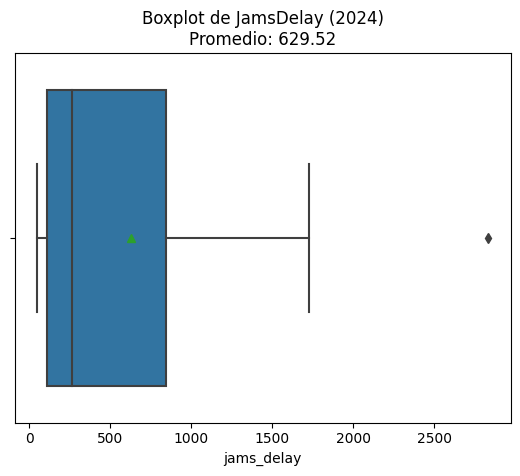

In [ ]:
# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
# crea tu gráfico
sns.boxplot(data=merged, x="jams_delay",showmeans=True)
# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.show()


Text(0.5, 1.0, 'distribución_gdp')

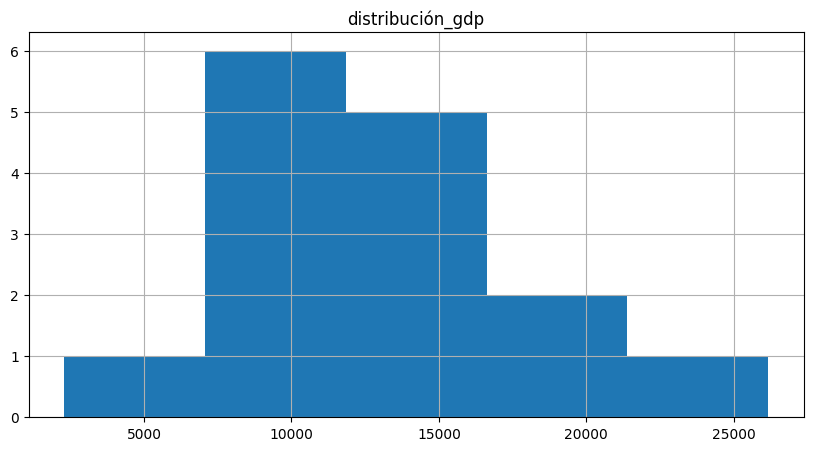

In [ ]:
# Crear histograma para ver la distribución de la economía (city_gdp_capita)
merged["city_gdp_capita"].hist(bins=5, figsize=(10,5))
plt.title("distribución_gdp")


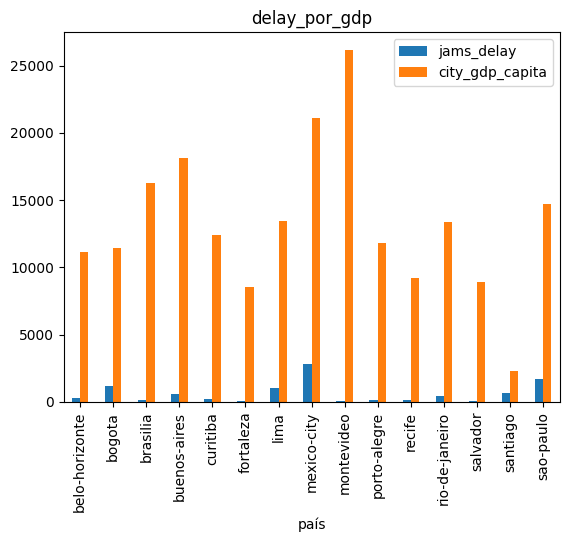

In [ ]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
merged.plot( x= "city", y=['jams_delay', 'city_gdp_capita'],kind="bar")
plt.title("delay_por_gdp")
plt.xlabel("país")
plt.xticks(rotation=90)
plt.show()

**Tip:** Antes del `plt.show()` agrega el código `plt.xticks(rotation=90)` para rotar las etiquetas del eje X en 90 grados.

Sí, existe una relación entre el PIB y el tráfico, la congestión es un síntoma de atividad económica, y las vías se han visto rebasadas por el exceso de vehículos transitando, existen unos casos de PIB alto y poco tráfico, pero habría que valorar si la falta de tráfico se debe a factores como el uso de transporte público, o si hay mas trabajos en remoto, o si la cantidad de vehículos es baja entre la población.


---

## 🧩Paso 7: Exportación de datos



In [ ]:
# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)


---

# 🧾 Resumen ejecutivo

**Contexto & objetivo:**  

El objetivo del análisis es, mostrar la relación entre el PIB y la movilidad urbana, para lograrlo se hizo uso de métricas como el País, la ciudad, el año, tasas de desempleo, gdp per capita, promedios de minutos para recorrer x distancia, para generar una lista que agrupe ciudades por país en el año 2024, donde el tráfico refleje una relación con el PIB de esa ciudad.

El analisis devolvió que existe una relación entre el tráfico y el PIB. El tráfico es un indicador de actividad económica,al haber mas crecimiento, mas personas, productos o servicios necesitan transitar en las vialidades, en este caso, sobrepasando la capacidad de las calles para que los vehículos puedan transitar.

**Cobertura de datos:**  
- Los datos usados fueron extraídos de TomTom Traffic index y de OECD Cities, abarcando 15 ciudades de latinoamerica de 7 paises diferentes (Brasil, Colombia, Argentina,Perú, México, Uruguay y Chile) en el año 2024

**Metodología (alto nivel):**  
Se realizó un proceso de limpieza y estandarización de los datos, incluyendo corrección de formatos numéricos y fechas, renombrado de columnas y tratamiento de variables económicas. Posteriormente, los datos de tráfico se agregaron por ciudad y año para obtener indicadores promedio representativos. Finalmente, ambos conjuntos de datos se integraron mediante una unión interna (INNER JOIN), generando una base consolidada para el análisis exploratorio y la visualización de patrones.

**Hallazgos iniciales:**  
Los resultados muestran una relación positiva entre la actividad económica y los niveles de congestión vehicular. En términos generales, las ciudades con mayor PIB per cápita también presentan mayores niveles de tráfico, lo que sugiere que la congestión puede ser una consecuencia del dinamismo económico y de una mayor demanda de movilidad. Sin embargo, también se identificaron ciudades con altos niveles de desarrollo económico y menor congestión relativa, lo que podría indicar una mejor infraestructura de transporte, una mayor adopción de transporte público o patrones laborales más flexibles.


**Recomendaciones**  
Ciudad de México, Bogotá, Lima, Santiago y São Paulo son las ciudades prioritarias para invertir en infraestructura de movilidad. Estas inversiones no deben enfocarse únicamente en la construcción de nuevas vialidades, sino también en la renovación, ampliación y modernización de los sistemas de transporte público, con el objetivo de reducir la cantidad de vehículos particulares en circulación y maximizar la movilidad de personas dentro de las áreas urbanas.

Otra medida recomendable es promover esquemas de trabajo híbrido o remoto en aquellos sectores donde sea viable, disminuyendo la necesidad de desplazamientos diarios hacia los principales centros económicos de las ciudades y contribuyendo a reducir la congestión vehicular.

Como análisis complementario, se sugiere estudiar la proporción de usuarios que se desplazan diariamente desde zonas metropolitanas o ciudades periféricas hacia los centros urbanos. En el caso de Ciudad de México, una parte importante del tráfico proviene de personas que residen fuera de la ciudad y se trasladan diariamente por motivos laborales. Esto permitiría identificar oportunidades para descentralizar la actividad económica y reducir la presión sobre la infraestructura vial.

Los resultados muestran que Santiago presenta niveles de congestión relativamente altos en comparación con su actividad económica, lo que la convierte en una de las ciudades prioritarias para futuras inversiones en infraestructura de transporte. Asimismo, podrían evaluarse estrategias complementarias, como una mayor adopción del trabajo remoto o esquemas laborales flexibles, para disminuir la demanda de movilidad durante las horas pico.

